# PTID-CDS-DEC-25-3624_PRCP-1015-EquakeDamagePred

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# configurations
import warnings
warnings.filterwarnings("ignore")

# seaborn plot style
sns.set(style="whitegrid")

In [3]:
# load dataset
url_labels = 'datasets/train_labels.csv'
data_labels = pd.read_csv(url_labels)

In [4]:
url_values = 'datasets/train_values.csv'
data_values = pd.read_csv(url_values)

In [5]:
print(data_labels.columns.tolist())

['building_id', 'damage_grade']


In [6]:
print(data_values.columns.tolist())

['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'legal_ownership_status', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', 'has_secondary_use_gov_office', 'has_secondary_use_use_police

## Data Aanalysis

First few rows of the dataset:


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,0
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,0
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,0


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   building_id                             260601 non-null  int64 
 1   geo_level_1_id                          260601 non-null  int64 
 2   geo_level_2_id                          260601 non-null  int64 
 3   geo_level_3_id                          260601 non-null  int64 
 4   count_floors_pre_eq                     260601 non-null  int64 
 5   age                                     260601 non-null  int64 
 6   area_percentage                         260601 non-null  int64 
 7   height_percentage                       260601 non-null  int64 
 8   land_surface_condition                  260601 non-null  object
 9   foundation_type                         260601 non-null  object
 10  roof_type                          

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
count,2.606010e+05,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,...,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000,260601.000000
mean,5.256755e+05,13.900353,701.074685,6257.876148,2.129723,26.535029,8.018051,5.434365,0.088645,0.761935,...,0.064378,0.033626,0.008101,0.000940,0.000361,0.001071,0.000188,0.000146,0.000088,0.005119
std,3.045450e+05,8.033617,412.710734,3646.369645,0.727665,73.565937,4.392231,1.918418,0.284231,0.425900,...,0.245426,0.180265,0.089638,0.030647,0.018989,0.032703,0.013711,0.012075,0.009394,0.071364
min,4.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.611900e+05,7.000000,350.000000,3073.000000,2.000000,10.000000,5.000000,4.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.257570e+05,12.000000,702.000000,6270.000000,2.000000,15.000000,7.000000,5.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.897620e+05,21.000000,1050.000000,9412.000000,2.000000,30.000000,9.000000,6.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.052934e+06,30.000000,1427.000000,12567.000000,9.000000,995.000000,100.000000,32.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Missing Values:


Series([], dtype: int64)

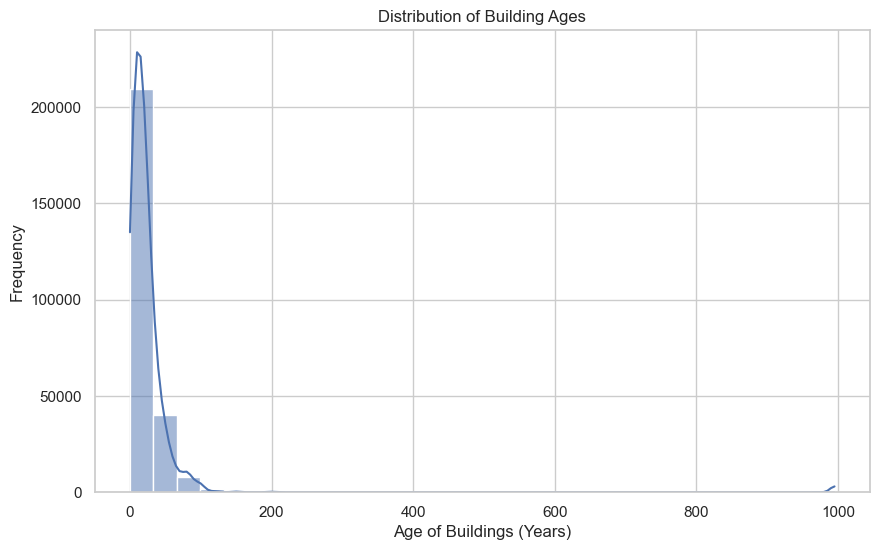

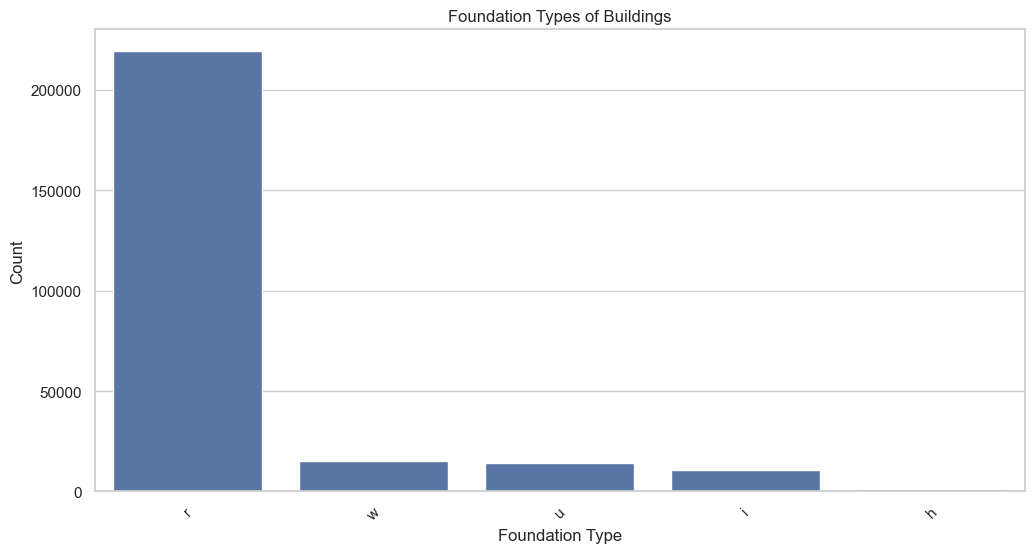

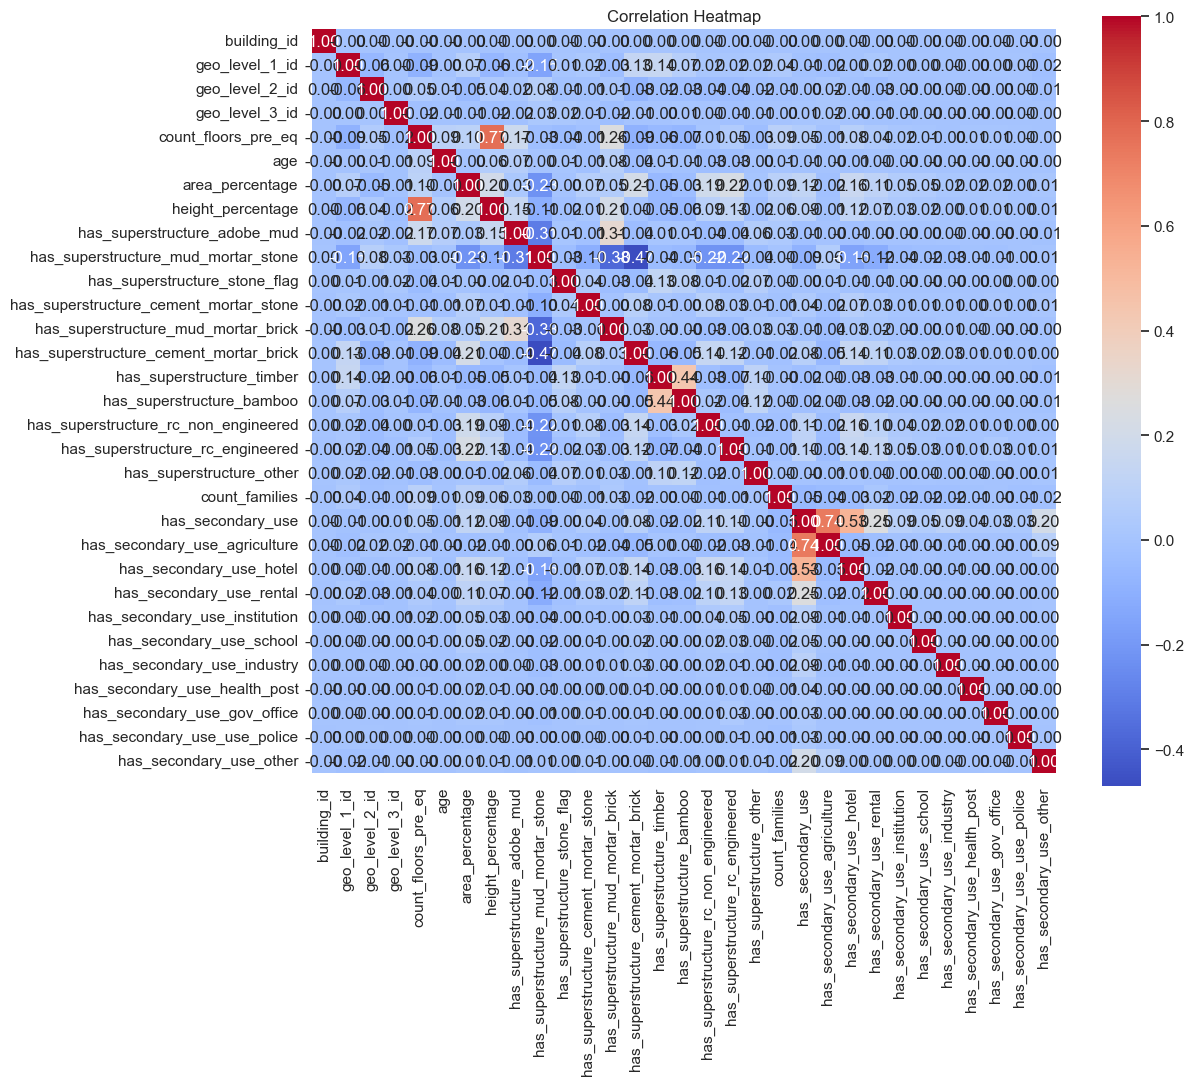

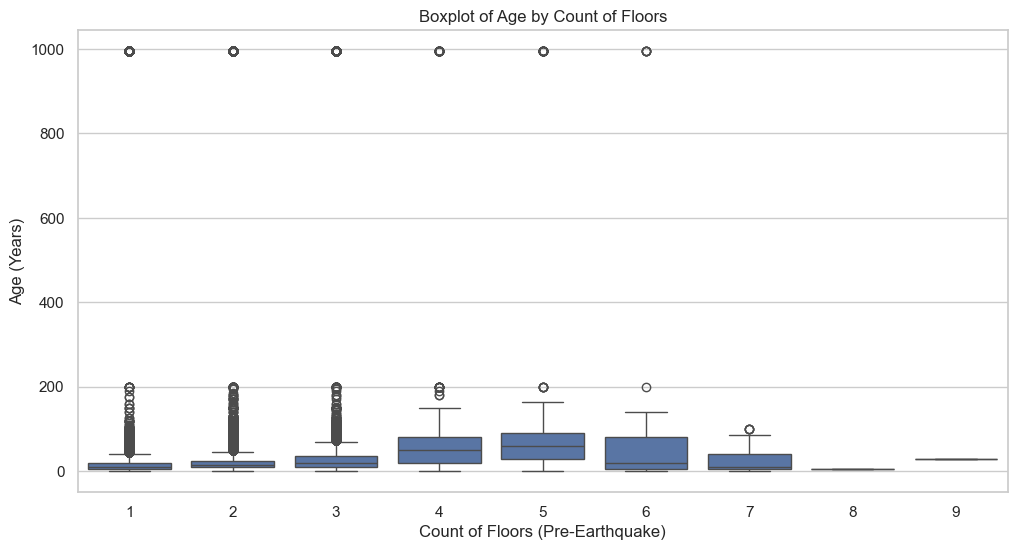

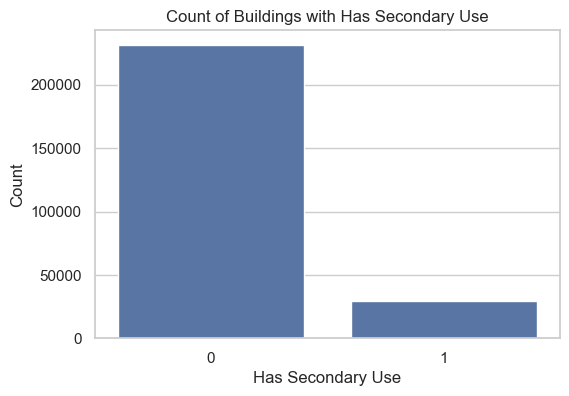

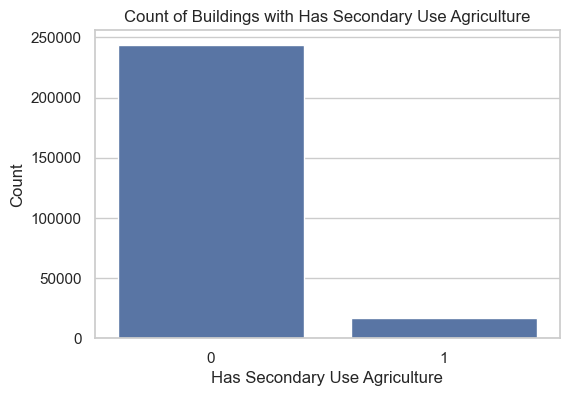

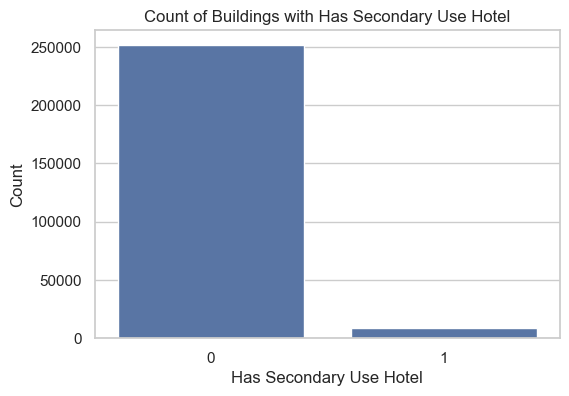

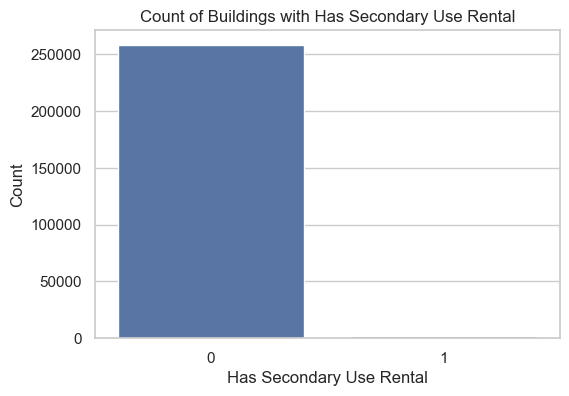

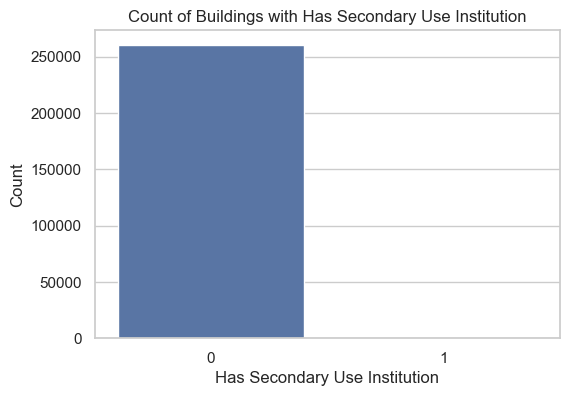

In [7]:
# display the first few rows of the dataset
print("First few rows of the dataset:")
display(data_values.head())

# display dataset information
print("Dataset Information:")
print(data_values.info())

# summary statistics
print("Summary Statistics:")
display(data_values.describe())

# check for missing values
missing_values = data_values.isnull().sum()
print("Missing Values:")
display(missing_values[missing_values > 0])

# visualizations

# histogram of the age of buildings
plt.figure(figsize=(10, 6))
sns.histplot(data_values['age'], bins=30, kde=True)
plt.title('Distribution of Building Ages')
plt.xlabel('Age of Buildings (Years)')
plt.ylabel('Frequency')
plt.show()

# countplot for foundation types
plt.figure(figsize=(12, 6))
sns.countplot(data=data_values, x='foundation_type', order=data_values['foundation_type'].value_counts().index)
plt.title('Foundation Types of Buildings')
plt.xlabel('Foundation Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

# correlation heatmap
plt.figure(figsize=(12, 10))
correlation = data_values.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Heatmap')
plt.show()

# boxplot for age vs count of floors
plt.figure(figsize=(12, 6))
sns.boxplot(x='count_floors_pre_eq', y='age', data=data_values)
plt.title('Boxplot of Age by Count of Floors')
plt.xlabel('Count of Floors (Pre-Earthquake)')
plt.ylabel('Age (Years)')
plt.show()

# ddditional analysis based on secondary use
secondary_use_columns = [
    'has_secondary_use', 
    'has_secondary_use_agriculture',
    'has_secondary_use_hotel',
    'has_secondary_use_rental',
    'has_secondary_use_institution'
]

for column in secondary_use_columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=data_values, x=column)
    plt.title(f'Count of Buildings with {column.replace("_", " ").title()}')
    plt.xlabel(column.replace("_", " ").title())
    plt.ylabel('Count')
    plt.show()

# Prediction

In [8]:
# import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# load the dataset
pvdata = data_values.copy()
pldata = data_labels.copy()

pdata = pd.merge(pvdata, pldata)

# handle missing values
pdata.fillna(method='ffill', inplace=True)  # forward fill or use an appropriate method

# check if damage_grade is present
if 'damage_grade' not in pdata.columns:
    raise ValueError("Column 'damage_grade' does not exist in the dataset.")

# encode categorical variables
categorical_cols = ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']

# drop columns that are not in the pvdataset if any
valid_categorical_cols = [col for col in categorical_cols if col in pdata.columns]

pdata = pd.get_dummies(pdata, columns=valid_categorical_cols, drop_first=True)

# define features and target variable
# using errors='ignore' to avoid errors
X = pdata.drop(columns=['damage_grade', 'building_id'], errors='ignore')
y = pdata['damage_grade']

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# make predictions
y_pred = model.predict(X_test)

# evaluate the model
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("Model training completed.")


[[ 2446  2615   109]
 [ 1089 24444  3954]
 [  117  6921 10426]]
              precision    recall  f1-score   support

           1       0.67      0.47      0.55      5170
           2       0.72      0.83      0.77     29487
           3       0.72      0.60      0.65     17464

    accuracy                           0.72     52121
   macro avg       0.70      0.63      0.66     52121
weighted avg       0.71      0.72      0.71     52121

Model training completed.


# Suggestions

In [9]:
# Load the dataset
svdata = data_values.copy()
sldata = data_labels.copy()

sdata = pd.merge(svdata, sldata)

# Display the first few rows of the dataset
print(sdata.head())

# Display dataset info to understand sssdata types and missing values
print(sdata.info())

   building_id  geo_level_1_id  geo_level_2_id  geo_level_3_id  \
0       802906               6             487           12198   
1        28830               8             900            2812   
2        94947              21             363            8973   
3       590882              22             418           10694   
4       201944              11             131            1488   

   count_floors_pre_eq  age  area_percentage  height_percentage  \
0                    2   30                6                  5   
1                    2   10                8                  7   
2                    2   10                5                  5   
3                    2   10                6                  5   
4                    3   30                8                  9   

  land_surface_condition foundation_type  ... has_secondary_use_hotel  \
0                      t               r  ...                       0   
1                      o               r  ...         

Columns in DataFrame: ['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'legal_ownership_status', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', 'has_secondary_use_gov_office', 'has_se

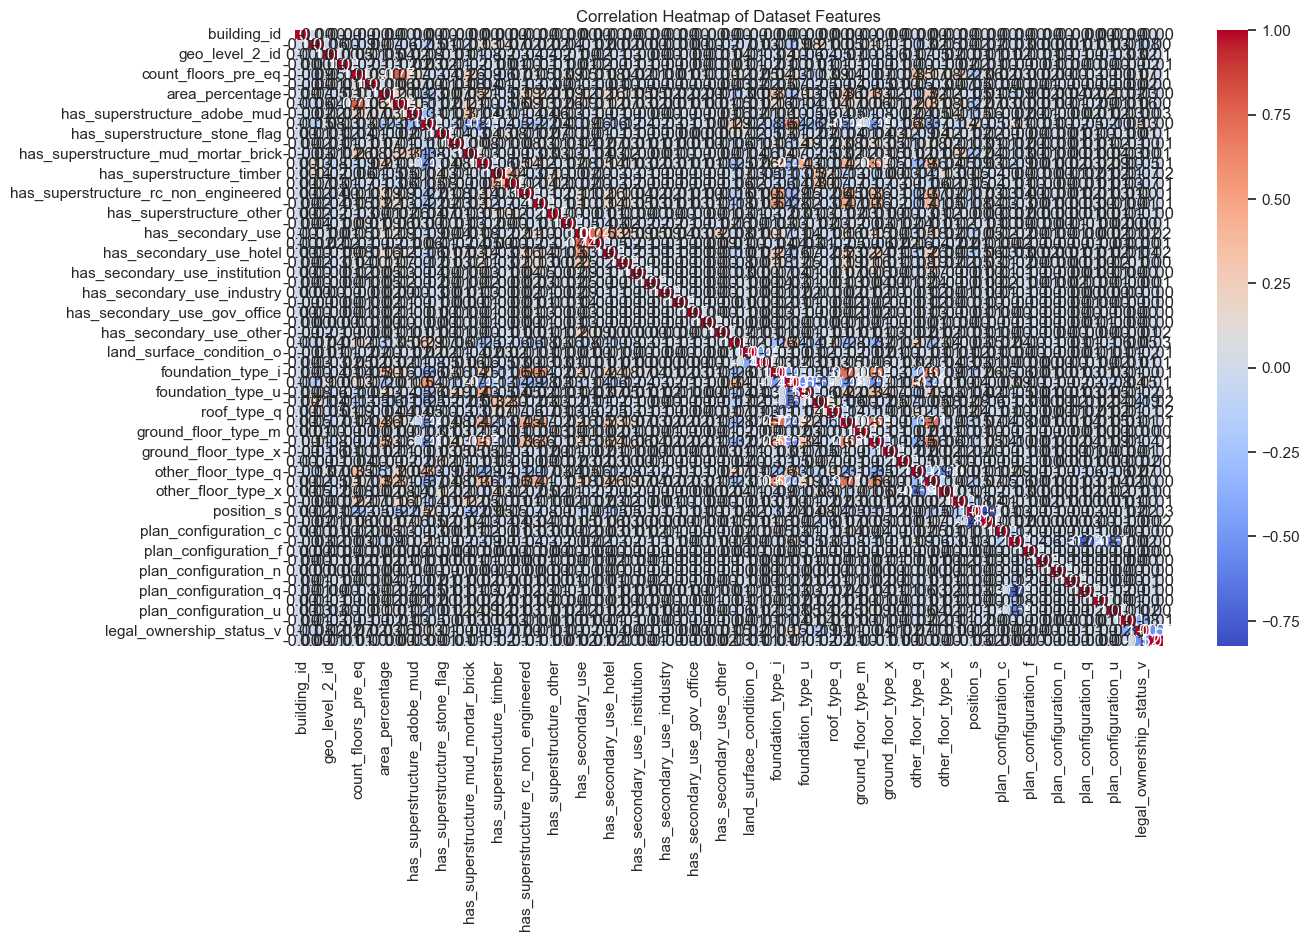

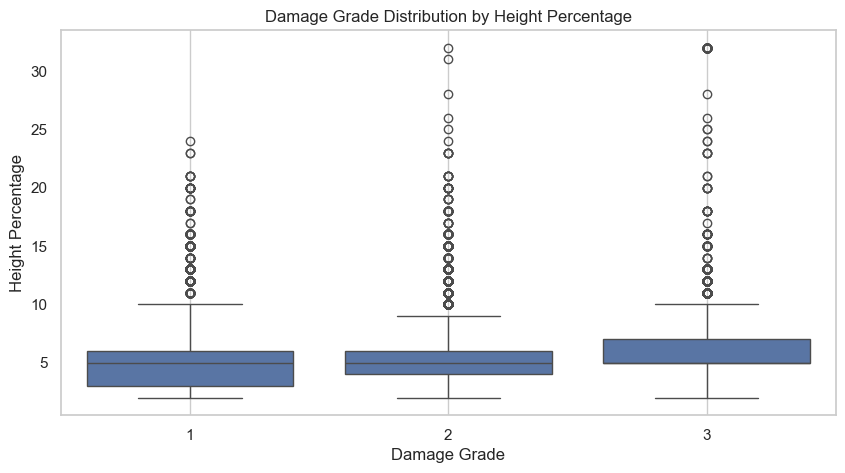

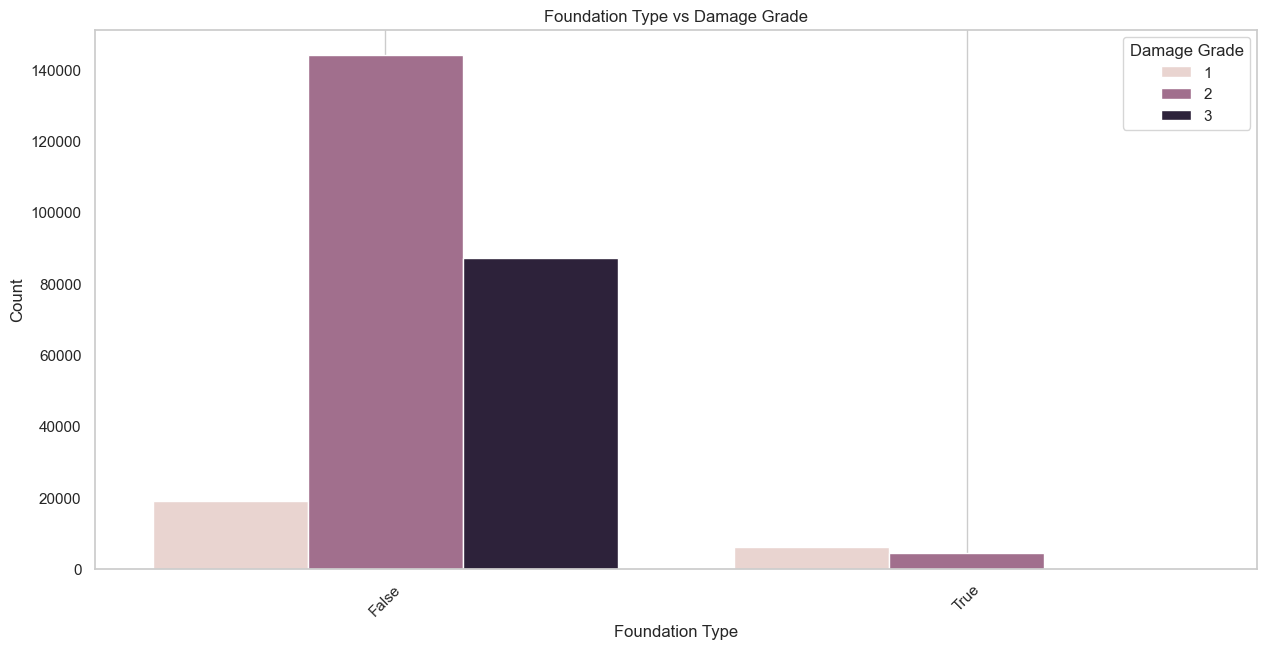

Improved Building Codes:
Implement stricter building codes that take into account various structural factors such as height and foundation type to enhance resilience against earthquakes.

Targeted Retrofitting:
Prioritize retrofitting older or vulnerable buildings that are likely to suffer more damage based on foundation types and building height.

Risk Assessment:
Conduct geological and structural assessments to identify and reinforce buildings located in high-risk zones.

Public Policy:
Create mandatory inspection policies for older buildings to ensure they meet current safety standards.

Community Education:
Educate the public on the importance of building practices and materials that contribute to earthquake resilience.

Emergency Preparedness Plans:
Develop comprehensive emergency response plans that account for various building types and their associated risks.



In [10]:
# check current columns in dataframe
print("Columns in DataFrame:", sdata.columns.tolist())

# convert categorical variables to numerical
# check for non-numeric columns
non_numeric_cols = sdata.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_cols)

# check unique values in non-numeric columns for unexpected strings
for col in non_numeric_cols:
    print(f"Unique values in {col}:", sdata[col].unique())

# define the columns to one-hot encode
categorical_cols = [
    'land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']

# ensure only existing categorical columns are converted
existing_categorical_cols = [col for col in categorical_cols if col in sdata.columns]

# using pandas' get_dummies to convert categorical variables to dummy variables
sdata = pd.get_dummies(sdata, columns=existing_categorical_cols, drop_first=True)

# convert damage_grade column to numeric
sdata['damage_grade'] = pd.to_numeric(sdata['damage_grade'], errors='coerce')

# remove rows with nan values
sdata.dropna(inplace=True)

# ensure damage_grade is now an integer or float
sdata['damage_grade'] = sdata['damage_grade'].astype(int)

# proceed to create visualizations
# correlation heatmap for dataset features
plt.figure(figsize=(14, 8))
corr_matrix = sdata.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Dataset Features')
plt.show()

# damage grade vs building height
plt.figure(figsize=(10, 5))
sns.boxplot(x='damage_grade', y='height_percentage', data=sdata)
plt.title('Damage Grade Distribution by Height Percentage')
plt.xlabel('Damage Grade')
plt.ylabel('Height Percentage')
plt.grid()
plt.show()

# damage grade vs foundation type 
existing_foundation_cols = [col for col in sdata.columns if 'foundation_type' in col]
plt.figure(figsize=(15, 7))
if existing_foundation_cols:  # Check if foundation_type columns exist
    sns.countplot(x=existing_foundation_cols[0], hue='damage_grade', data=sdata)
    plt.title('Foundation Type vs Damage Grade')
    plt.xlabel('Foundation Type')
    plt.ylabel('Count')
    plt.legend(title='Damage Grade')
    plt.xticks(rotation=45)
    plt.grid()
    plt.show()
else:
    print("No foundation type columns to plot.")

# suggestions based on analysis results
suggestions = {
    "Improved Building Codes": (
        "Implement stricter building codes that take into account various structural factors such as height and foundation type to enhance resilience against earthquakes."
    ),
    "Targeted Retrofitting": (
        "Prioritize retrofitting older or vulnerable buildings that are likely to suffer more damage based on foundation types and building height."
    ),
    "Risk Assessment": (
        "Conduct geological and structural assessments to identify and reinforce buildings located in high-risk zones."
    ),
    "Public Policy": (
        "Create mandatory inspection policies for older buildings to ensure they meet current safety standards."
    ),
    "Community Education": (
        "Educate the public on the importance of building practices and materials that contribute to earthquake resilience."
    ),
    "Emergency Preparedness Plans": (
        "Develop comprehensive emergency response plans that account for various building types and their associated risks."
    )
}

# Display the suggestions in a more structured manner
for title, suggestion in suggestions.items():
    print(f"{title}:\n{suggestion}\n")
